# 🏦 Détection de Fraude Bancaire
## Projet Machine Learning — Decision Tree + XGBoost
**Auteur :** MBOGHE Mussi sephora cara | **Niveau :** L3 S2

---
### Méthodologie suivie
1. **Chargement & aperçu des données**
2. **Analyse Descriptive** — comprendre la structure du dataset
3. **Nettoyage des Données** — valeurs manquantes, outliers, encodage, rééquilibrage
4. **Modélisation** — Decision Tree élagué + XGBoost
5. **Évaluation** — Matrice de confusion, ROC, Cross-validation
6. **Prédiction** — tester sur un nouvel exemple


## 0. Installation & Imports

In [3]:
# Installation des librairies (décommenter si nécessaire)
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

import xgboost as xgb

# ── Palette graphique cohérente avec l'app ──────────────────────
BLEU_FONCE = "#0D1B2A"
BLEU_MOYEN = "#1B3A5C"
BLEU_CLAIR = "#2E7DAF"
ACCENT     = "#E8C547"
ROUGE      = "#E05C4B"
VERT       = "#4CAF50"
BLANC      = "#F5F5F0"

plt.rcParams.update({
    "figure.facecolor"  : BLEU_FONCE,
    "axes.facecolor"    : BLEU_MOYEN,
    "axes.labelcolor"   : BLANC,
    "axes.titlecolor"   : ACCENT,
    "xtick.color"       : BLANC,
    "ytick.color"       : BLANC,
    "text.color"        : BLANC,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.spines.left"  : False,
    "axes.spines.bottom": False,
    "font.family"       : "DejaVu Sans",
})

print("✅ Imports OK")


✅ Imports OK


## 1. Chargement des Données

> **Comment charger votre fichier ?**
> - Placez votre fichier CSV dans le même dossier que ce notebook
> - Remplacez `"votre_fichier.csv"` par le nom exact de votre fichier
> - Si votre colonne cible ne s'appelle pas `"Class"`, modifiez la variable `TARGET`


In [4]:
# ── Paramètre à adapter ──────────────────────────────────────────
FICHIER = "fraude_bancaire_synthetique_final.csv"   # ← Remplacez par le nom de votre fichier
TARGET  = "fraude"               # ← Nom de la colonne cible (0=légitime, 1=fraude)
SEP     = ","                   # Séparateur CSV (virgule par défaut)

# ── Chargement ────────────────────────────────────────────────────
df = pd.read_csv(FICHIER, sep=SEP)

print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Colonnes : {list(df.columns)}")


✅ Dataset chargé : 1,020 lignes × 9 colonnes
   Colonnes : ['age', 'salaire', 'score_credit', 'montant_transaction', 'anciennete_compte', 'type_carte', 'region', 'genre', 'fraude']


In [5]:
# Aperçu des 5 premières lignes
df.head()


,age,salaire,score_credit,montant_transaction,anciennete_compte,type_carte,region,genre,fraude
0,49.548894,183659.045784,48.228579,9.649456e+06,14.0,Mastercard,Houston,femelle,0.0
1,44.952665,329732.599158,67.573097,2.500000e+04,NaN,Mastercard,Houston,femelle,0.0
2,41.659910,75000.000000,77.559487,2.724004e+06,9.0,Visa,Houston,male,0.0
3,42.377280,75000.000000,54.282220,4.755632e+06,9.0,Mastercard,Orlando,femelle,0.0
4,48.125023,359999.482942,71.148546,2.500000e+04,8.0,Mastercard,Orlando,femelle,0.0


In [6]:
# Types de données et valeurs manquantes globales
print("Types de données :")
print(df.dtypes)
print(f"\nValeurs manquantes totales : {df.isnull().sum().sum()}")


Types de données :
age                    float64
salaire                float64
score_credit           float64
montant_transaction    float64
anciennete_compte      float64
type_carte              object
region                  object
genre                   object
fraude                 float64
dtype: object

Valeurs manquantes totales : 203


## 2. Analyse Descriptive

L'analyse descriptive permet de **comprendre la structure des données** avant tout traitement.
On s'intéresse notamment à :
- La **distribution de la variable cible** (déséquilibre de classes ?)
- Les **statistiques de chaque variable** (moyenne, médiane, écart-type)
- Les **valeurs manquantes**
- Les **corrélations** entre variables


=== Distribution de la variable cible ===
fraude
0.0    937
1.0     45
Name: count, dtype: int64

Pourcentage de fraude : 4.58 %


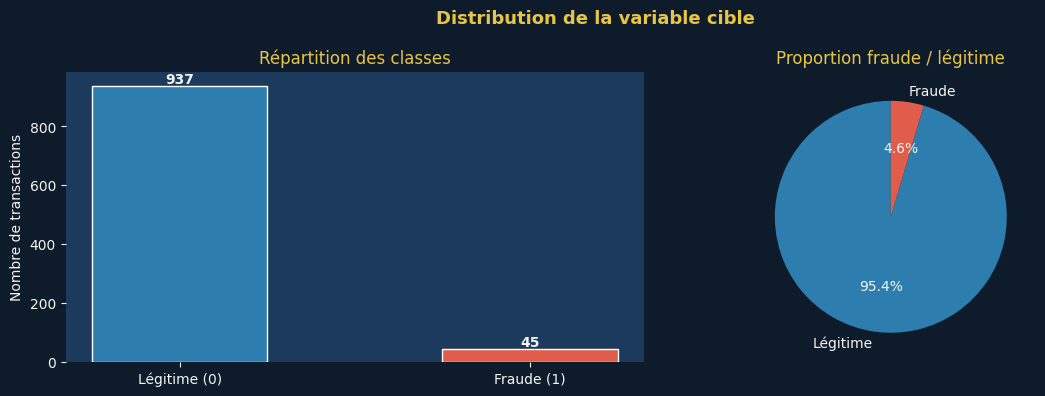

In [7]:
# ── 2.1 Distribution de la variable cible ───────────────────────
print("=== Distribution de la variable cible ===")
print(df[TARGET].value_counts())
print(f"\nPourcentage de fraude : {df[TARGET].mean()*100:.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique barres
counts = df[TARGET].value_counts()
axes[0].bar(["Légitime (0)", "Fraude (1)"], counts.values,
            color=[BLEU_CLAIR, ROUGE], edgecolor="white", width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts)*0.01, f"{v:,}", ha="center",
                 color=BLANC, fontweight="bold")
axes[0].set_title("Répartition des classes")
axes[0].set_ylabel("Nombre de transactions")

# Camembert
axes[1].pie(counts.values, labels=["Légitime", "Fraude"],
            colors=[BLEU_CLAIR, ROUGE],
            autopct="%1.1f%%", startangle=90,
            textprops={"color": BLANC})
axes[1].set_title("Proportion fraude / légitime")

plt.suptitle("Distribution de la variable cible", color=ACCENT,
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

# ── Interprétation ────────────────────────────────────────────────
# IMPORTANT : si la fraude représente moins de 5 % des transactions,
# on parle de DÉSÉQUILIBRE DE CLASSES.
# Le modèle risque d'ignorer la fraude et de tout prédire "légitime".
# → Solution : oversampling (voir étape Nettoyage)


In [8]:
# ── 2.2 Statistiques descriptives ───────────────────────────────
print("=== Statistiques descriptives ===")
df.describe().T.style.background_gradient(cmap="Blues")


=== Statistiques descriptives ===


,count,mean,std,min,25%,50%,75%,max
age,1003.000000,40.408051,7.805954,24.000000,35.205528,40.452085,45.614974,60.000000
salaire,1002.000000,297164.636768,136089.166672,75000.000000,195695.682449,294562.124263,391034.624076,715256.040844
score_credit,998.000000,49.567810,19.142124,3.000000,36.335605,49.642099,62.795183,99.000000
montant_transaction,996.000000,5088725.017080,2843704.074404,25000.000000,3118899.199296,4982902.574885,6926265.752799,15133304.723868
anciennete_compte,999.000000,9.655656,4.815800,1.000000,6.000000,10.000000,13.000000,25.000000
fraude,982.000000,0.045825,0.209212,0.000000,0.000000,0.000000,0.000000,1.000000


Colonnes avec valeurs manquantes :
age                    17
salaire                18
score_credit           22
montant_transaction    24
anciennete_compte      21
type_carte             23
region                 17
genre                  23
fraude                 38
dtype: int64


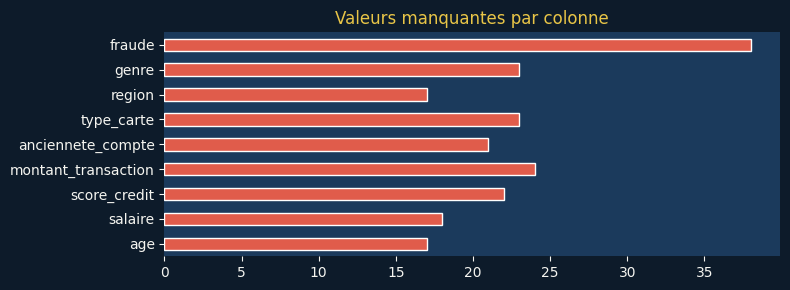

In [9]:
# ── 2.3 Valeurs manquantes par colonne ───────────────────────────
manquantes = df.isnull().sum()
manquantes = manquantes[manquantes > 0]

if manquantes.empty:
    print("✅ Aucune valeur manquante détectée !")
else:
    print("Colonnes avec valeurs manquantes :")
    print(manquantes)
    fig, ax = plt.subplots(figsize=(8, 3))
    manquantes.plot(kind="barh", ax=ax, color=ROUGE, edgecolor="white")
    ax.set_title("Valeurs manquantes par colonne")
    plt.tight_layout()
    plt.show()


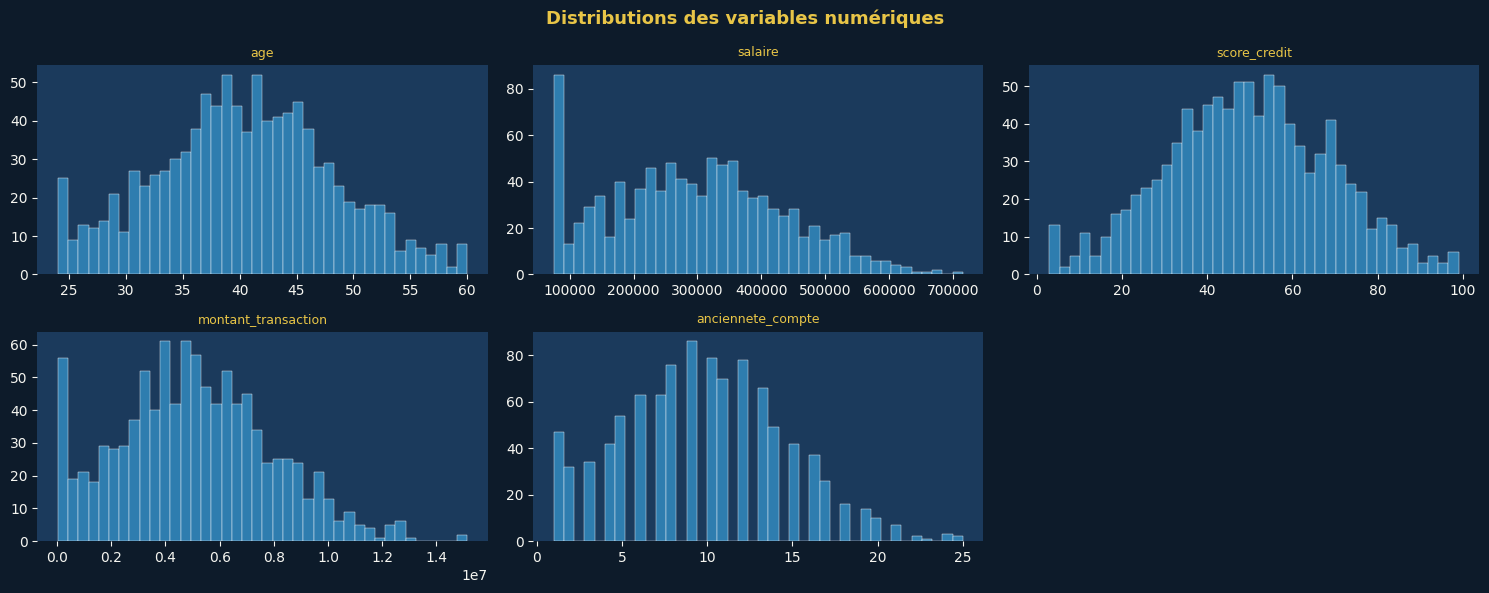

In [10]:
# ── 2.4 Distributions des variables numériques ──────────────────
numeriques = df.select_dtypes(include=np.number).columns.tolist()
if TARGET in numeriques:
    numeriques.remove(TARGET)

n_cols = 3
n_rows = (len(numeriques) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(numeriques):
    axes[i].hist(df[col].dropna(), bins=40, color=BLEU_CLAIR,
                 edgecolor="white", linewidth=0.3)
    axes[i].set_title(col, fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions des variables numériques",
             color=ACCENT, fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


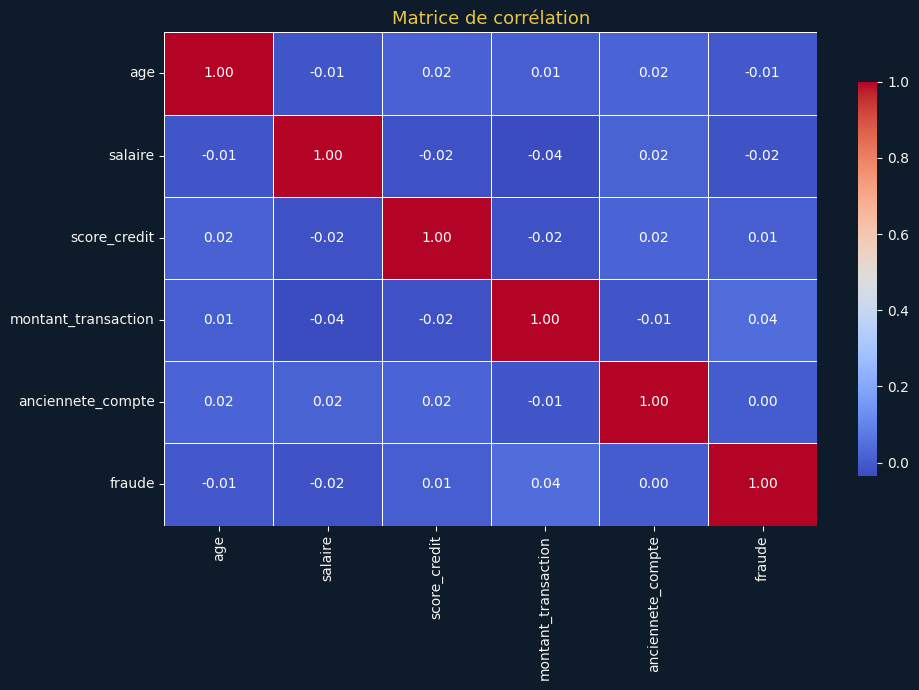

In [11]:
# ── 2.5 Matrice de corrélation ───────────────────────────────────
# La corrélation mesure le lien linéaire entre deux variables (-1 à 1).
# On cherche les variables les plus corrélées à la cible.

num_df = df.select_dtypes(include=np.number)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    num_df.corr(), ax=ax,
    cmap="coolwarm",
    annot=(len(num_df.columns) <= 10),
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Matrice de corrélation", fontsize=13)
plt.tight_layout()
plt.show()


## 3. Nettoyage des Données

Le nettoyage se déroule en 5 étapes ordonnées :

| Étape | Technique | Pourquoi ? |
|-------|-----------|------------|
| 1 | Suppression des doublons | Évite de biaiser l'entraînement |
| 2 | Traitement des valeurs manquantes | Sklearn ne supporte pas les NaN |
| 3 | Encodage (LabelEncoder) | Transformer les textes en nombres |
| 4 | Suppression des outliers (IQR) | Réduire le bruit dans les données |
| 5 | Rééquilibrage (Oversampling) | Corriger le déséquilibre de classes |


In [12]:
df_propre = df.copy()
n_initial = len(df_propre)

# ── Étape 1 : Suppression des doublons ───────────────────────────
n_avant = len(df_propre)
df_propre = df_propre.drop_duplicates()
print(f"[1] Doublons supprimés : {n_avant - len(df_propre):,}")

# ── Étape 2 : Valeurs manquantes ─────────────────────────────────
# On remplace par la médiane (robuste aux outliers) pour les numériques
# et par le mode (valeur la plus fréquente) pour les catégorielles.
for col in df_propre.columns:
    if df_propre[col].isnull().any():
        if df_propre[col].dtype in [np.float64, np.int64, np.float32, np.int32]:
            df_propre[col].fillna(df_propre[col].median(), inplace=True)
        else:
            df_propre[col].fillna(df_propre[col].mode()[0], inplace=True)
print(f"[2] Valeurs manquantes traitées (médiane/mode)")

# ── Étape 3 : Encodage LabelEncoder ──────────────────────────────
# LabelEncoder convertit chaque catégorie en entier : ["A","B","C"] → [0,1,2]
# Sklearn ne peut pas travailler avec du texte directement.
encodeurs = {}
colonnes_cat = df_propre.select_dtypes(include=["object","category"]).columns
colonnes_cat = [c for c in colonnes_cat if c != TARGET]

for col in colonnes_cat:
    le = LabelEncoder()
    df_propre[col] = le.fit_transform(df_propre[col].astype(str))
    encodeurs[col] = le
print(f"[3] Colonnes encodées : {list(colonnes_cat) if len(colonnes_cat) > 0 else 'Aucune (déjà numériques)'}")

# ── Étape 4 : Outliers (méthode IQR) ─────────────────────────────
# Q1 = 25e percentile, Q3 = 75e percentile, IQR = Q3 - Q1
# Borne basse = Q1 - 1.5*IQR | Borne haute = Q3 + 1.5*IQR
# Toute valeur hors de ces bornes est considérée aberrante.
features_num = [c for c in df_propre.select_dtypes(include=np.number).columns
                if c != TARGET]
n_avant = len(df_propre)
for col in features_num:
    Q1  = df_propre[col].quantile(0.25)
    Q3  = df_propre[col].quantile(0.75)
    IQR = Q3 - Q1
    masque = (df_propre[col] >= Q1 - 1.5*IQR) & (df_propre[col] <= Q3 + 1.5*IQR)
    df_propre = df_propre[masque]
print(f"[4] Outliers supprimés (IQR) : {n_avant - len(df_propre):,} lignes")

# ── Étape 5 : Rééquilibrage des classes (Oversampling) ───────────
# On duplique aléatoirement les exemples de la classe minoritaire (fraude)
# jusqu'à atteindre le même nombre que la classe majoritaire.
idx_max   = df_propre[TARGET].value_counts().idxmax()
idx_min   = df_propre[TARGET].value_counts().idxmin()
majeur    = df_propre[df_propre[TARGET] == idx_max]
mineur    = df_propre[df_propre[TARGET] == idx_min]
mineur_up = resample(mineur, replace=True, n_samples=len(majeur), random_state=42)
df_propre = pd.concat([majeur, mineur_up]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"[5] Classes rééquilibrées → total : {len(df_propre):,} lignes")

# ── Bilan ─────────────────────────────────────────────────────────
print(f"\n📋 Bilan nettoyage")
print(f"   Lignes initiales : {n_initial:,}")
print(f"   Lignes finales   : {len(df_propre):,}")
print(f"   Distribution finale :")
print(df_propre[TARGET].value_counts())


[1] Doublons supprimés : 10
[2] Valeurs manquantes traitées (médiane/mode)
[3] Colonnes encodées : ['type_carte', 'region', 'genre']
[4] Outliers supprimés (IQR) : 15 lignes
[5] Classes rééquilibrées → total : 1,900 lignes

📋 Bilan nettoyage
   Lignes initiales : 1,020
   Lignes finales   : 1,900
   Distribution finale :
fraude
1.0    950
0.0    950
Name: count, dtype: int64


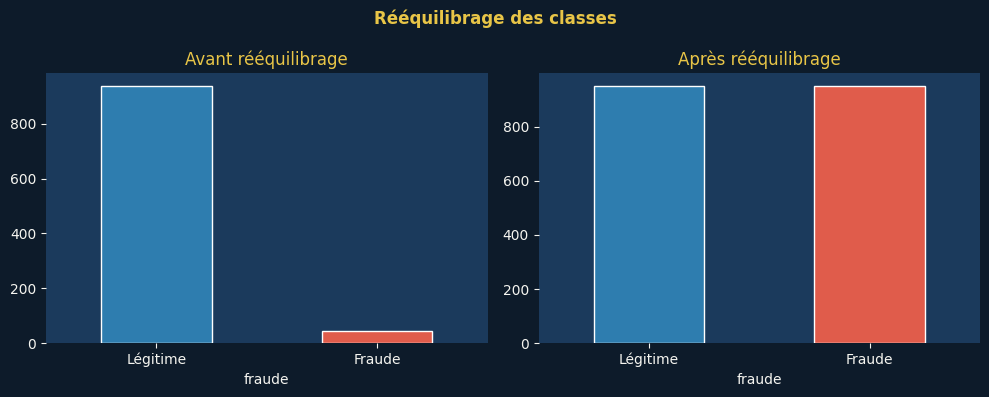

In [13]:
# Visualisation : avant / après rééquilibrage
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df[TARGET].value_counts().plot(kind="bar", ax=axes[0],
    color=[BLEU_CLAIR, ROUGE], edgecolor="white")
axes[0].set_title("Avant rééquilibrage")
axes[0].set_xticklabels(["Légitime", "Fraude"], rotation=0)

df_propre[TARGET].value_counts().plot(kind="bar", ax=axes[1],
    color=[BLEU_CLAIR, ROUGE], edgecolor="white")
axes[1].set_title("Après rééquilibrage")
axes[1].set_xticklabels(["Légitime", "Fraude"], rotation=0)

plt.suptitle("Rééquilibrage des classes", color=ACCENT, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Modélisation

On entraîne **deux modèles** :

### 🌳 Decision Tree élagué (Pruning)
Sans contrainte, un Decision Tree mémorise chaque exemple d'entraînement → **sur-apprentissage**.
On le contrôle avec 3 hyperparamètres :
- `max_depth` : profondeur maximale de l'arbre
- `min_samples_leaf` : nombre minimum d'exemples dans une feuille
- `min_samples_split` : nombre minimum d'exemples pour diviser un nœud

### 🚀 XGBoost (eXtreme Gradient Boosting)
Ensemble de **petits arbres** entraînés séquentiellement : chaque arbre corrige les erreurs du précédent.
Naturellement résistant au sur-apprentissage grâce au **taux d'apprentissage** (`learning_rate`).


In [14]:
# ── Préparation train/test ────────────────────────────────────────
FEATURES = [c for c in df_propre.columns if c != TARGET]

X = df_propre[FEATURES].values
y = df_propre[TARGET].values

# On réserve 20 % des données pour l'évaluation (jamais vues à l'entraînement)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20 % pour le test
    random_state=42,     # reproductibilité
    stratify=y           # conserver la proportion de chaque classe
)

print(f"Entraînement : {X_train.shape[0]:,} exemples")
print(f"Test         : {X_test.shape[0]:,} exemples")
print(f"Features     : {FEATURES}")


Entraînement : 1,520 exemples
Test         : 380 exemples
Features     : ['age', 'salaire', 'score_credit', 'montant_transaction', 'anciennete_compte', 'type_carte', 'region', 'genre']


In [15]:
# ── 4.1 Decision Tree élagué ─────────────────────────────────────
# Hyperparamètres d'élagage — modifiez-les pour observer l'effet
MAX_DEPTH        = 5    # Profondeur max (↑ = plus complexe, risque sur-apprentissage)
MIN_SAMPLES_LEAF = 10   # Min exemples par feuille (↑ = arbre plus simple)
MIN_SAMPLES_SPLIT= 20   # Min exemples pour couper (↑ = moins de coupures)

dt = DecisionTreeClassifier(
    max_depth         = MAX_DEPTH,
    min_samples_leaf  = MIN_SAMPLES_LEAF,
    min_samples_split = MIN_SAMPLES_SPLIT,
    random_state      = 42
)
dt.fit(X_train, y_train)

print(f"✅ Decision Tree entraîné")
print(f"   Profondeur réelle   : {dt.get_depth()}")
print(f"   Nombre de feuilles  : {dt.get_n_leaves()}")


✅ Decision Tree entraîné
   Profondeur réelle   : 5
   Nombre de feuilles  : 7


In [16]:
# ── 4.2 XGBoost ──────────────────────────────────────────────────
N_ESTIMATORS  = 100    # Nombre d'arbres (↑ = plus puissant mais plus lent)
XGB_DEPTH     = 4      # Profondeur par arbre (petits arbres = moins de sur-apprentissage)
LEARNING_RATE = 0.10   # Taux d'apprentissage (↓ = plus prudent, souvent meilleur)

xgb_model = xgb.XGBClassifier(
    n_estimators  = N_ESTIMATORS,
    max_depth     = XGB_DEPTH,
    learning_rate = LEARNING_RATE,
    eval_metric   = "logloss",   # métrique interne d'optimisation
    random_state  = 42,
    verbosity     = 0
)
xgb_model.fit(X_train, y_train)

print("✅ XGBoost entraîné")


✅ XGBoost entraîné


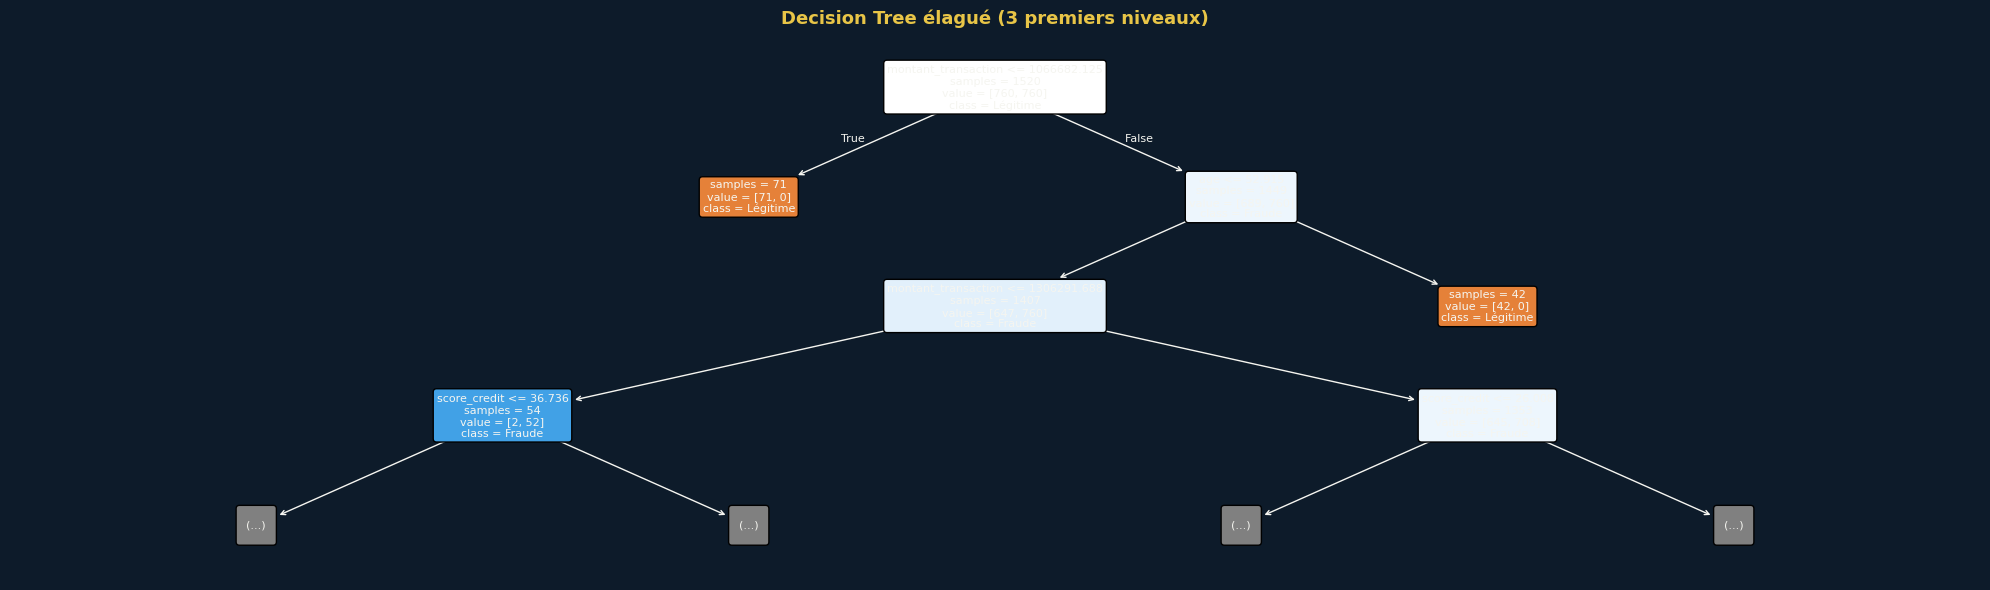

In [17]:
# ── Visualisation de l'arbre de décision (élagué) ───────────────
# Uniquement les 3 premiers niveaux pour la lisibilité
fig, ax = plt.subplots(figsize=(20, 6), facecolor=BLEU_FONCE)
ax.set_facecolor(BLEU_FONCE)
plot_tree(
    dt,
    max_depth        = 3,
    feature_names    = FEATURES,
    class_names      = ["Légitime", "Fraude"],
    filled           = True,
    rounded          = True,
    fontsize         = 8,
    ax               = ax,
    impurity         = False
)
ax.set_title("Decision Tree élagué (3 premiers niveaux)", color=ACCENT,
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


## 5. Évaluation des Modèles

On évalue chaque modèle avec plusieurs outils complémentaires :

| Outil | Ce qu'il mesure |
|-------|-----------------|
| **Accuracy** | % de prédictions correctes (toutes classes) |
| **Matrice de confusion** | Détail des erreurs (faux positifs, faux négatifs) |
| **AUC-ROC** | Capacité à distinguer fraude / légitime (0.5=aléatoire, 1=parfait) |
| **Cross-validation** | Robustesse du modèle sur différents sous-ensembles |
| **Rapport de classification** | Précision, rappel et F1 par classe |


In [18]:
# ── Prédictions ──────────────────────────────────────────────────
y_pred_dt  = dt.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

y_prob_dt  = dt.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ── Métriques globales ────────────────────────────────────────────
acc_dt   = accuracy_score(y_test, y_pred_dt)
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
auc_dt   = roc_auc_score(y_test, y_prob_dt)
auc_xgb  = roc_auc_score(y_test, y_prob_xgb)

print("=" * 50)
print(f"{'Modèle':<25} {'Accuracy':>10} {'AUC-ROC':>10}")
print("=" * 50)
print(f"{'Decision Tree élagué':<25} {acc_dt:>10.4f} {auc_dt:>10.4f}")
print(f"{'XGBoost':<25} {acc_xgb:>10.4f} {auc_xgb:>10.4f}")
print("=" * 50)


Modèle                      Accuracy    AUC-ROC
Decision Tree élagué          0.6421     0.6627
XGBoost                       0.9553     0.9943


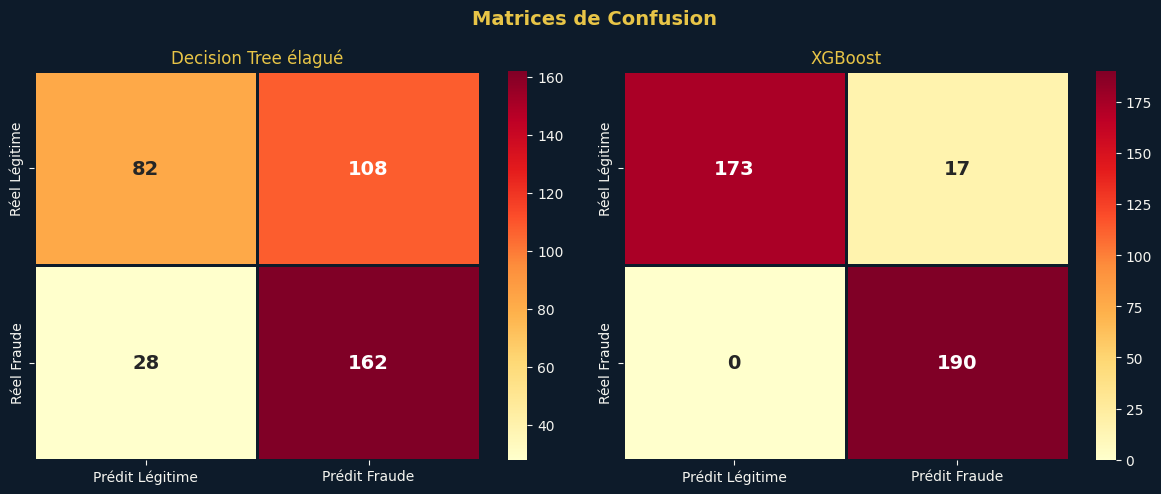

In [19]:
# ── Matrices de confusion ────────────────────────────────────────
# La matrice de confusion montre :
#   Ligne 0 = transactions légitimes réelles
#   Ligne 1 = transactions frauduleuses réelles
#   Colonne 0 = prédites légitimes | Colonne 1 = prédites frauduleuses
#
#   Case [0,0] = Vrais Négatifs  (légitimes bien classés)
#   Case [1,1] = Vrais Positifs  (fraudes bien détectées) ← on veut maximiser
#   Case [0,1] = Faux Positifs   (légitimes classés fraude) → alarmes inutiles
#   Case [1,0] = Faux Négatifs   (fraudes non détectées) → DANGEREUX 🚨

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, titre in [
    (axes[0], y_pred_dt,  "Decision Tree élagué"),
    (axes[1], y_pred_xgb, "XGBoost"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                cmap="YlOrRd",
                xticklabels=["Prédit Légitime", "Prédit Fraude"],
                yticklabels=["Réel Légitime", "Réel Fraude"],
                linewidths=1, linecolor=BLEU_FONCE,
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(titre, fontsize=12)

plt.suptitle("Matrices de Confusion", color=ACCENT, fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()


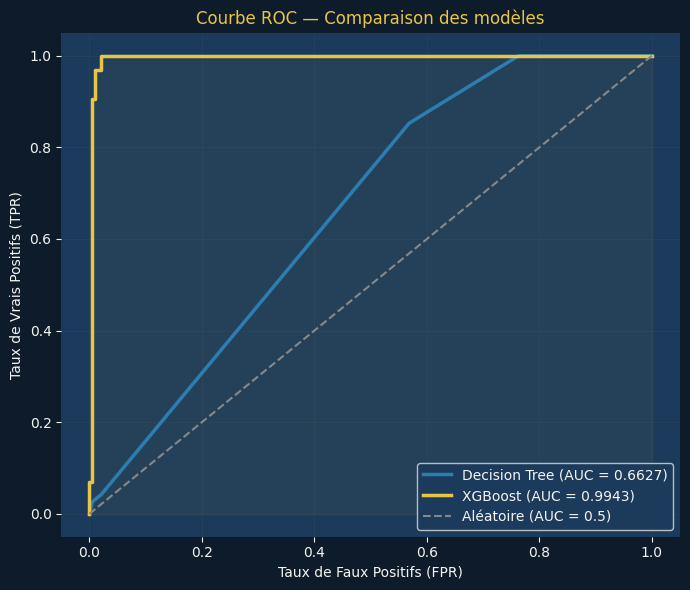

In [20]:
# ── Courbe ROC ───────────────────────────────────────────────────
# La courbe ROC montre le compromis entre :
#   TPR (True Positive Rate) = fraudes correctement détectées
#   FPR (False Positive Rate) = légitimes incorrectement classées fraude
#
# Plus la courbe est proche du coin supérieur gauche, meilleur est le modèle.
# L'AUC (aire sous la courbe) synthétise la qualité : 1.0 = parfait, 0.5 = hasard.

fig, ax = plt.subplots(figsize=(7, 6))

for y_prob, label, color in [
    (y_prob_dt,  f"Decision Tree (AUC = {auc_dt:.4f})",  BLEU_CLAIR),
    (y_prob_xgb, f"XGBoost (AUC = {auc_xgb:.4f})",       ACCENT),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=label)

ax.plot([0,1], [0,1], "--", color="#888", linewidth=1.5, label="Aléatoire (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=0.05, color=ACCENT)

ax.set_xlabel("Taux de Faux Positifs (FPR)")
ax.set_ylabel("Taux de Vrais Positifs (TPR)")
ax.set_title("Courbe ROC — Comparaison des modèles")
ax.legend(loc="lower right", facecolor=BLEU_MOYEN, framealpha=0.9)
ax.grid(alpha=0.2, color="#555")
plt.tight_layout()
plt.show()


In [21]:
# ── Cross-validation 5-fold ──────────────────────────────────────
# On divise les données en 5 parties (folds).
# On entraîne 5 fois en utilisant une partie différente comme test à chaque fois.
# La moyenne des 5 AUC donne une estimation fiable et non biaisée.

print("=== Cross-Validation 5-fold (AUC-ROC) ===\n")

for modele, nom in [(dt, "Decision Tree élagué"), (xgb_model, "XGBoost")]:
    scores = cross_val_score(modele, X, y, cv=5, scoring="roc_auc")
    print(f"{nom}")
    print(f"  Scores    : {' | '.join([f'{s:.4f}' for s in scores])}")
    print(f"  Moyenne   : {scores.mean():.4f}")
    print(f"  Écart-type: {scores.std():.4f}  (↓ = modèle stable)\n")


=== Cross-Validation 5-fold (AUC-ROC) ===

Decision Tree élagué
  Scores    : 0.7240 | 0.7453 | 0.7859 | 0.6966 | 0.7523
  Moyenne   : 0.7408
  Écart-type: 0.0297  (↓ = modèle stable)

XGBoost
  Scores    : 0.9986 | 0.9947 | 0.9983 | 0.9986 | 0.9994
  Moyenne   : 0.9979
  Écart-type: 0.0017  (↓ = modèle stable)



In [22]:
# ── Rapport de classification ────────────────────────────────────
# Pour chaque classe :
#   Précision = parmi les prédits fraude, combien l'étaient vraiment ?
#   Rappel    = parmi les vraies fraudes, combien ont été détectées ?
#   F1-score  = harmonie entre précision et rappel

print("=== Rapport de classification — Decision Tree élagué ===")
print(classification_report(y_test, y_pred_dt,
      target_names=["Légitime", "Fraude"]))

print("\n=== Rapport de classification — XGBoost ===")
print(classification_report(y_test, y_pred_xgb,
      target_names=["Légitime", "Fraude"]))


=== Rapport de classification — Decision Tree élagué ===
              precision    recall  f1-score   support

    Légitime       0.75      0.43      0.55       190
      Fraude       0.60      0.85      0.70       190

    accuracy                           0.64       380
   macro avg       0.67      0.64      0.63       380
weighted avg       0.67      0.64      0.63       380


=== Rapport de classification — XGBoost ===
              precision    recall  f1-score   support

    Légitime       1.00      0.91      0.95       190
      Fraude       0.92      1.00      0.96       190

    accuracy                           0.96       380
   macro avg       0.96      0.96      0.96       380
weighted avg       0.96      0.96      0.96       380



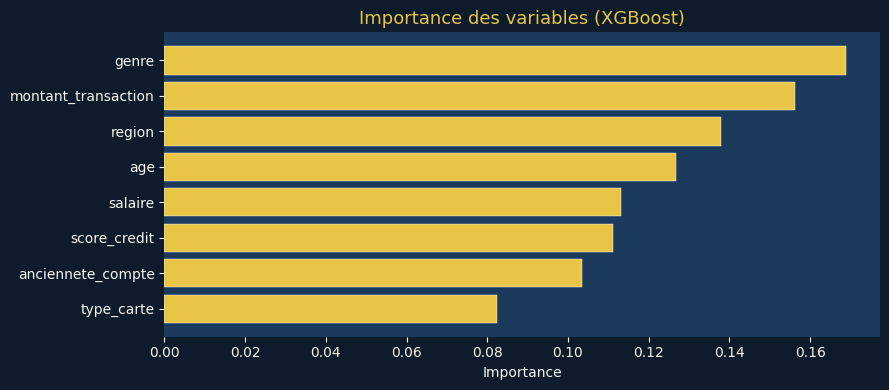

In [23]:
# ── Importance des features (XGBoost) ────────────────────────────
# Montre quelles variables influencent le plus les décisions du modèle.
# Les variables avec une importance proche de 0 sont potentiellement inutiles.

importances = xgb_model.feature_importances_
idx         = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, max(4, len(FEATURES)*0.35)))
ax.barh(
    [FEATURES[i] for i in idx[::-1]],
    importances[idx[::-1]],
    color=ACCENT, edgecolor="white", linewidth=0.3
)
ax.set_title("Importance des variables (XGBoost)", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 6. Prédiction sur un Nouvel Exemple

Cette étape simule le déploiement : on soumet une **nouvelle transaction** aux deux modèles
et on obtient un verdict avec une probabilité de fraude.

> **À personnaliser :** remplacez les valeurs dans `NOUVELLE_TRANSACTION` par les valeurs réelles de la transaction à tester.


In [24]:
# ── Saisir les valeurs de la nouvelle transaction ────────────────
# Remplacez les valeurs ci-dessous par celles de votre transaction.
# L'ordre DOIT correspondre exactement à FEATURES.

# Exemple : on prend la médiane de chaque colonne comme valeur de référence
# (à remplacer par des vraies valeurs)
NOUVELLE_TRANSACTION = {
    feature: float(df_propre[feature].median())
    for feature in FEATURES
}

# ── Affichage des valeurs saisies ────────────────────────────────
print("Transaction à analyser :")
for k, v in NOUVELLE_TRANSACTION.items():
    print(f"  {k:30s} : {v:.4f}")


Transaction à analyser :
  age                            : 40.7783
  salaire                        : 292167.8530
  score_credit                   : 48.7159
  montant_transaction            : 5215504.9502
  anciennete_compte              : 10.0000
  type_carte                     : 1.0000
  region                         : 1.0000
  genre                          : 1.0000


In [25]:
# ── Prédiction ────────────────────────────────────────────────────
X_nouveau = np.array([[NOUVELLE_TRANSACTION[f] for f in FEATURES]])

# Decision Tree
pred_dt  = dt.predict(X_nouveau)[0]
prob_dt  = dt.predict_proba(X_nouveau)[0][1]

# XGBoost
pred_xgb = xgb_model.predict(X_nouveau)[0]
prob_xgb = xgb_model.predict_proba(X_nouveau)[0][1]

# ── Affichage du verdict ──────────────────────────────────────────
print("=" * 55)
print(f"{'RÉSULTATS DE LA PRÉDICTION':^55}")
print("=" * 55)

for nom, pred, prob in [
    ("Decision Tree élagué", pred_dt,  prob_dt),
    ("XGBoost",              pred_xgb, prob_xgb),
]:
    verdict = "🔴 FRAUDE DÉTECTÉE" if pred == 1 else "🟢 TRANSACTION LÉGITIME"
    print(f"\n  {nom}")
    print(f"  Verdict  : {verdict}")
    print(f"  Proba fraude : {prob:.1%}")
    print(f"  {'━'*40}")

print()
if pred_dt == pred_xgb:
    print("✅ Les deux modèles sont d'accord → Prédiction fiable")
else:
    print("⚠️  Les modèles divergent → Résultat incertain")
    print("   On privilégie XGBoost (généralement plus précis)")
    print("   Une vérification manuelle est recommandée")


              RÉSULTATS DE LA PRÉDICTION               

  Decision Tree élagué
  Verdict  : 🔴 FRAUDE DÉTECTÉE
  Proba fraude : 60.1%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  XGBoost
  Verdict  : 🔴 FRAUDE DÉTECTÉE
  Proba fraude : 51.8%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ Les deux modèles sont d'accord → Prédiction fiable


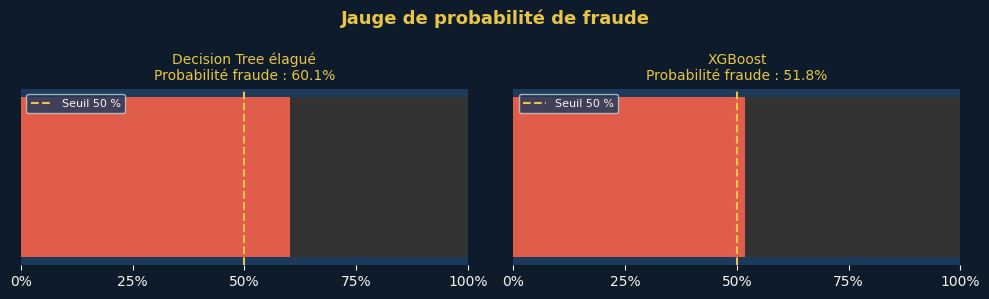

In [26]:
# ── Visualisation de la probabilité de fraude ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for ax, prob, nom in [
    (axes[0], prob_dt,  "Decision Tree élagué"),
    (axes[1], prob_xgb, "XGBoost"),
]:
    couleur = ROUGE if prob >= 0.5 else VERT
    ax.barh(0, 1,    height=0.4, color="#333")
    ax.barh(0, prob, height=0.4, color=couleur)
    ax.axvline(0.5, color=ACCENT, linestyle="--", linewidth=1.5,
               label="Seuil 50 %")
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.set_title(f"{nom}\nProbabilité fraude : {prob:.1%}", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle("Jauge de probabilité de fraude", color=ACCENT,
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


## 7. Conclusion

### Récapitulatif de la méthodologie

| Étape | Action | Résultat |
|-------|--------|----------|
| **Analyse** | Distribution, corrélations, stats | Compréhension du dataset |
| **Nettoyage** | Doublons, NaN, IQR, oversampling | Données prêtes pour le modèle |
| **Modélisation** | DT élagué + XGBoost | Deux modèles complémentaires |
| **Évaluation** | Confusion, ROC, Cross-val | Validation rigoureuse |
| **Prédiction** | Formulaire de saisie | Déploiement opérationnel |

### Points clés retenus

- Le **sur-apprentissage** est corrigé par l'élagage du Decision Tree et par la nature même de XGBoost
- Le **déséquilibre de classes** est résolu par l'oversampling avant l'entraînement
- La **cross-validation** garantit que les performances ne sont pas dues au hasard
- En cas de **divergence des deux modèles**, XGBoost est généralement préféré

---
*Projet réalisé par MBOGHE Mussi — L3 S2 Machine Learning*
